In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========================
# ==== CONFIG ============
# ========================
# model_topk_2_norm_std_noise_True_ep_100_lr_0.001 horizon_12
# model_topk_2_norm_std_noise_True_ep_100_lr_0.001 horizon_3
# model_topk_2_norm_std_noise_True_ep_30_lr_0.001 horizon_6
# model_topk_2_norm_std_noise_True_ep_30_lr_0.001 horizon_24

results_path = "RESULTADOS_COMPLETOS_ANP/results_by_state_year/model_topk_2_norm_std_noise_True_ep_100_lr_0.001"

all_data = []

# ========================
# ==== LOAD & MERGE ======
# ========================
for root, _, files in os.walk(results_path):
    subfolder = os.path.basename(root)
    
    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        parts = file.replace(".csv", "").split("_")
        year = int(parts[-1])
        state = parts[-2].upper()

        df_long = df.melt(
            id_vars=["Modelo"],
            var_name="Produto",
            value_name="MAPE"
        )

        df_long["Year"] = year
        df_long["State"] = state
        df_long["horizonte"] = subfolder 

        all_data.append(df_long)

# ========================
# ==== CLEANUP ===========
# ========================
df_all = pd.concat(all_data, ignore_index=True)

df_all = df_all[df_all["Produto"] != "Unnamed: 0"]

df_all = (
    df_all
    .replace([float("inf"), float("-inf")], pd.NA)
    .dropna(subset=["MAPE"])
)


In [3]:
target_products = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

df_all = df_all[df_all["Produto"].isin(target_products)]

print(df_all.head())


     Modelo          Produto     MAPE  Year State   horizonte
0  Time-MoE  Etanolhidratado   8.4121  2020    AC  horizon_12
1     Timer  Etanolhidratado  26.0507  2020    AC  horizon_12
2   TimesFM  Etanolhidratado  15.2568  2020    AC  horizon_12
3    Moirai  Etanolhidratado   9.7387  2020    AC  horizon_12
4   Chronos  Etanolhidratado  23.7416  2020    AC  horizon_12


Computing Bayesian comparison matrices...
Generating plots...



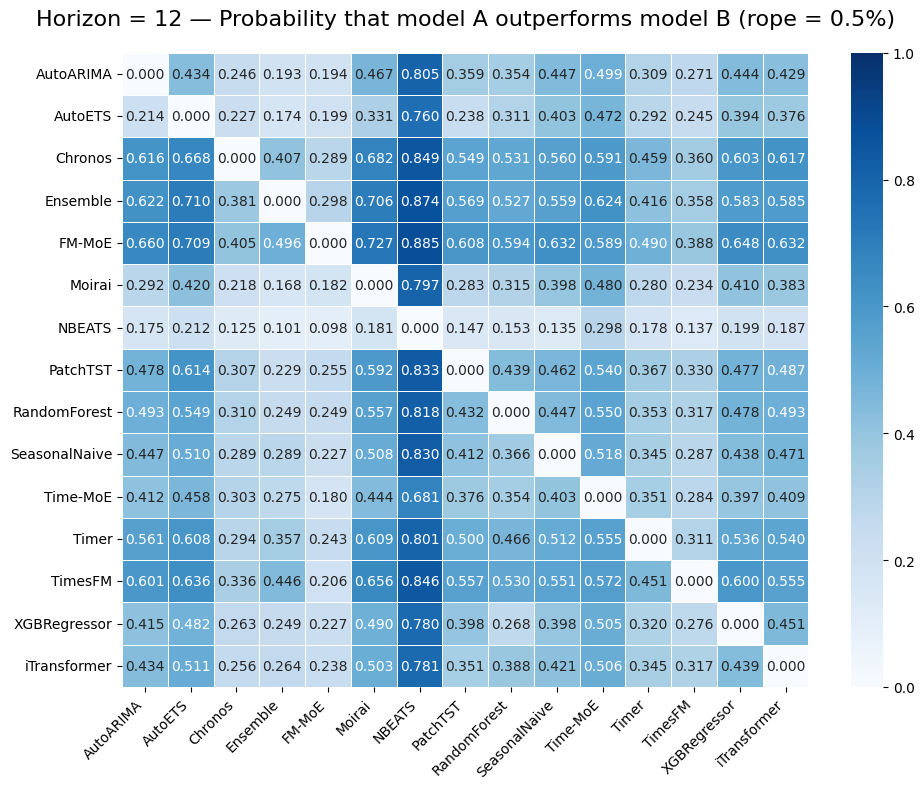

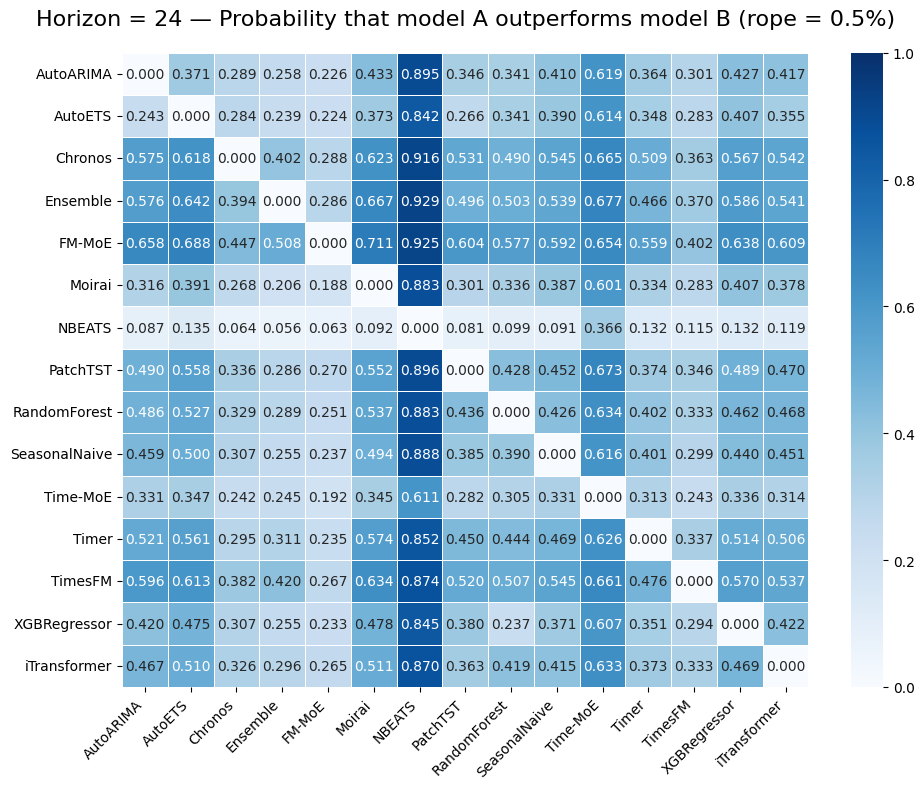

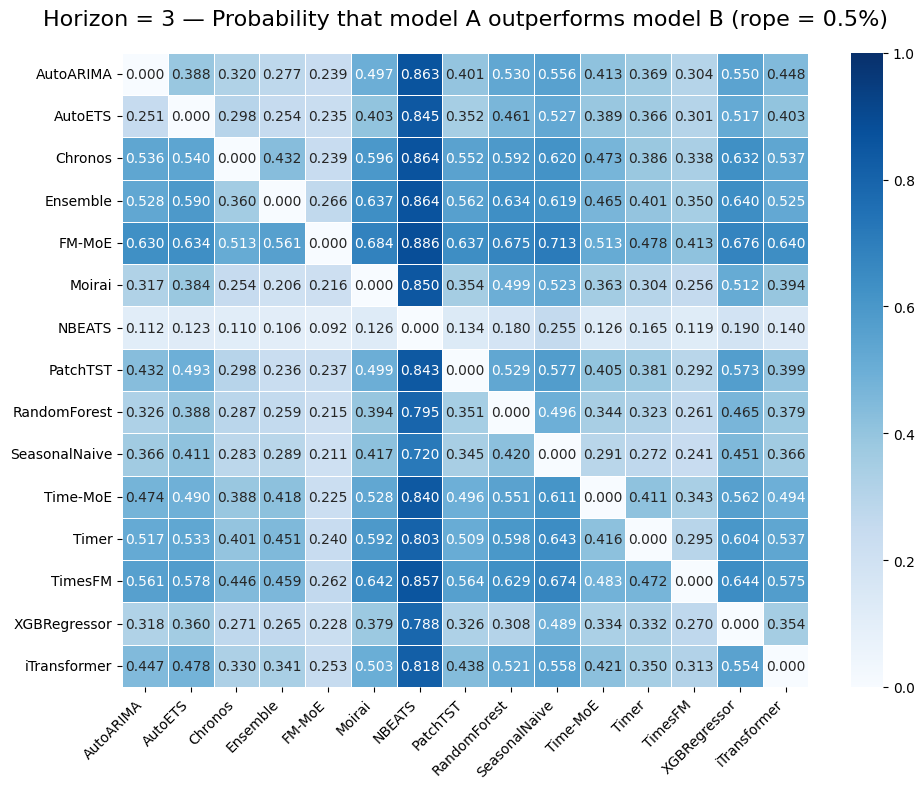

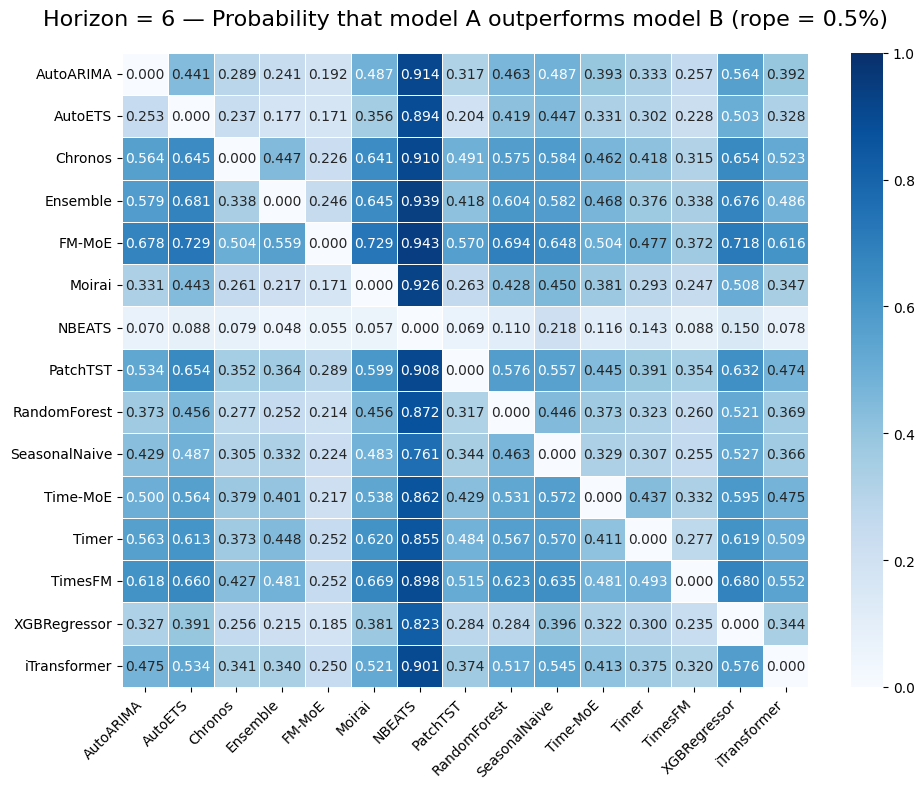

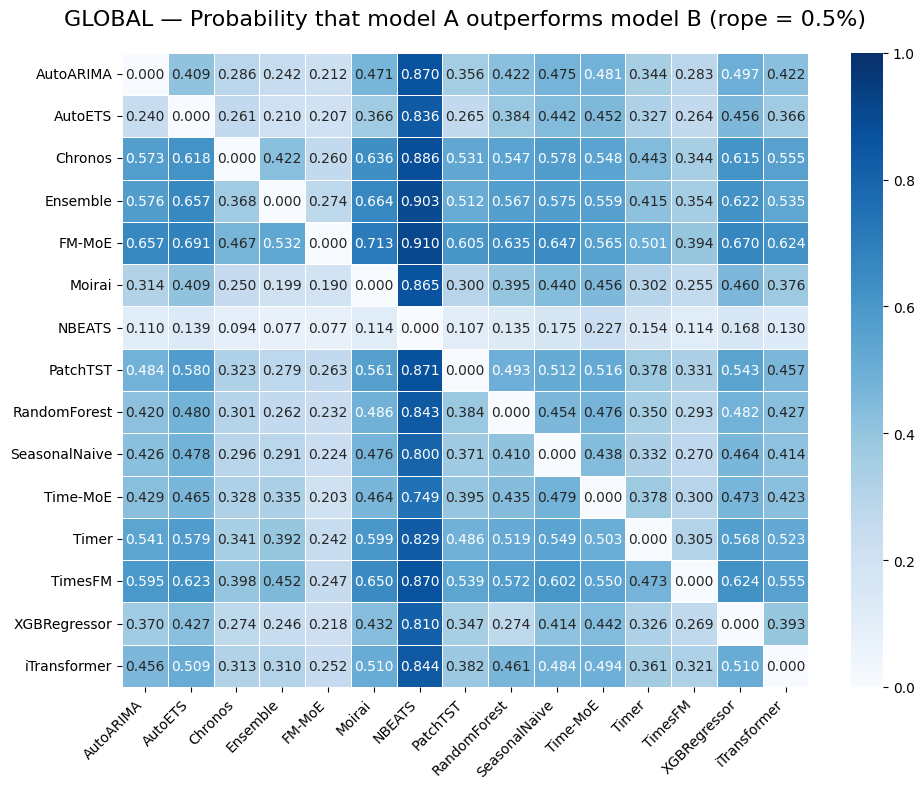

In [4]:
# ================================================
#  IMPORTS
# ================================================
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


# ================================================
#  RENAME MODEL (FM-MoE -> FM-MoE)
# ================================================
df_all["Modelo"] = df_all["Modelo"].replace("FM-MoE", "FM-MoE")
df_all["Modelo"] = df_all["Modelo"].replace("Morai", "Moirai")


# ================================================
#  1. BAYESIAN SIGNED-RANK TEST
# ================================================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):
    """
    Bayesian Signed-Rank Test.

    differences : array of differences (B - A)
    rope        : region of practical equivalence (e.g., 0.5 = 0.5% MAPE)
    s           : Dirichlet prior pseudo-count (0.5 recommended)
    """

    diffs = np.array(differences)

    n_left = np.sum(diffs < -rope)          # B is better
    n_rope = np.sum(np.abs(diffs) <= rope)  # equivalent
    n_right = np.sum(diffs > rope)          # A is better

    alpha = np.array([n_left + s, n_rope + s, n_right + s])

    posterior = np.random.dirichlet(alpha, size=5000)

    theta_left = posterior[:, 0].mean()
    theta_rope = posterior[:, 1].mean()
    theta_right = posterior[:, 2].mean()

    return theta_left, theta_rope, theta_right


# ================================================
#  2. BUILD BAYESIAN COMPARISON MATRIX
# ================================================
def bayesian_matrix(df, rope=0.5, metric="MAPE"):

    models = sorted(df["Modelo"].unique())

    mat_better = pd.DataFrame(0.0, index=models, columns=models)
    mat_rope = pd.DataFrame(0.0, index=models, columns=models)

    for A, B in combinations(models, 2):

        dfA = df[df["Modelo"] == A][metric].values
        dfB = df[df["Modelo"] == B][metric].values

        if len(dfA) != len(dfB):
            raise ValueError(f"Models {A} and {B} have different sizes after filtering.")

        # Smaller error = better model
        diffs = dfB - dfA

        theta_left, theta_rope, theta_right = bayesian_signed_rank(diffs, rope)

        mat_better.loc[A, B] = theta_right
        mat_better.loc[B, A] = theta_left

        mat_rope.loc[A, B] = theta_rope
        mat_rope.loc[B, A] = theta_rope

    return mat_better, mat_rope


# ================================================
#  3. PLOT BAYESIAN MATRIX
# ================================================
def plot_bayesian_matrix(matrix, title=""):

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=True
    )

    ax.set_title(title, fontsize=16, pad=20)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# ================================================
#  4. RUN BAYESIAN TESTS BY HORIZON AND GLOBAL
# ================================================
def run_bayesian_tests_by_horizon_and_global(df_all, rope=0.5, metric="MAPE"):

    results = {}

    # A) BY HORIZON
    for horizon in df_all["horizonte"].unique():

        subset = df_all[df_all["horizonte"] == horizon]

        if len(subset["Modelo"].unique()) > 1:

            mat_better, mat_rope = bayesian_matrix(subset, rope, metric)

            results[("HORIZON", horizon)] = {
                "matrix_better": mat_better,
                "matrix_rope": mat_rope
            }

    # B) GLOBAL
    if len(df_all["Modelo"].unique()) > 1:

        mat_better, mat_rope = bayesian_matrix(df_all, rope, metric)

        results[("GLOBAL", "ALL_HORIZONS")] = {
            "matrix_better": mat_better,
            "matrix_rope": mat_rope
        }

    return results


# =============================================================
#  5. RUN EVERYTHING AND GENERATE PLOTS
# =============================================================
rope = 0.5

print("Computing Bayesian comparison matrices...")

results = run_bayesian_tests_by_horizon_and_global(
    df_all,
    rope=rope,
    metric="MAPE"
)

print("Generating plots...\n")

for key, res in results.items():

    category, value = key

    if category == "GLOBAL":

        title = f"GLOBAL — Probability that model A outperforms model B (rope = {rope}%)"

    else:

        # Convert "horizon_12" -> 12
        horizon_number = str(value).split("_")[-1]

        title = f"Horizon = {horizon_number} — Probability that model A outperforms model B (rope = {rope}%)"

    plot_bayesian_matrix(res["matrix_better"], title)

In [1]:
import os
import numpy as np
import pandas as pd

# ========================
# CONFIG
# ========================
BASE_RESULTS_PATH = "RESULTADOS_COMPLETOS_ANP/results_by_state_year"
MY_MOE_NAME = "FM-MoE"
ROPE = 0.5
TOP_K = 5

target_products = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

# ========================
# BAYESIAN FUNCTIONS
# ========================
def bayesian_signed_rank(differences, rope=0.5, s=0.5):

    diffs = np.array(differences)

    n_left  = np.sum(diffs < -rope)
    n_rope  = np.sum(np.abs(diffs) <= rope)
    n_right = np.sum(diffs > rope)

    alpha = np.array([n_left + s, n_rope + s, n_right + s])

    posterior = np.random.dirichlet(alpha, size=5000)

    return posterior.mean(axis=0)


def prob_A_better_than_B(df, A, B, rope=0.5, metric="MAPE"):

    dfA = df[df["Modelo"] == A][metric].values
    dfB = df[df["Modelo"] == B][metric].values

    if len(dfA) != len(dfB):
        raise ValueError(f"{A} e {B} com tamanhos diferentes.")

    diffs = dfB - dfA

    _, _, theta_A_better = bayesian_signed_rank(diffs, rope)

    return theta_A_better


# ========================
# PROCESSAMENTO
# ========================

results_by_horizon = {}

for experiment_name in sorted(os.listdir(BASE_RESULTS_PATH)):

    experiment_path = os.path.join(BASE_RESULTS_PATH, experiment_name)

    if not os.path.isdir(experiment_path):
        continue

    # cada experimento possui horizon_x
    for horizon_folder in sorted(os.listdir(experiment_path)):

        if "horizon" not in horizon_folder:
            continue

        horizon_path = os.path.join(experiment_path, horizon_folder)

        all_data = []

        for file in os.listdir(horizon_path):

            if not file.endswith(".csv"):
                continue

            df = pd.read_csv(os.path.join(horizon_path, file))

            parts = file.replace(".csv", "").split("_")
            year = int(parts[-1])
            state = parts[-2].upper()

            df_long = df.melt(
                id_vars=["Modelo"],
                var_name="Produto",
                value_name="MAPE"
            )

            df_long["Year"] = year
            df_long["State"] = state

            all_data.append(df_long)

        if not all_data:
            continue

        df_all = pd.concat(all_data, ignore_index=True)

        df_all = (
            df_all
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["MAPE"])
        )

        df_all = df_all[df_all["Produto"].isin(target_products)]

        modelos = df_all["Modelo"].unique()

        my_moe_models = [m for m in modelos if MY_MOE_NAME in m]

        if not my_moe_models:
            continue

        my_moe = my_moe_models[0]

        row = {
            "Experimento": experiment_name,
            "Horizon": horizon_folder
        }

        probs = []

        for other_model in modelos:

            if other_model == my_moe:
                continue

            p = prob_A_better_than_B(df_all, my_moe, other_model, rope=ROPE)

            row[f"Prob_MyMoE_vs_{other_model}"] = p
            probs.append(p)

        row["Score_Medio_MyMoE"] = np.mean(probs)

        if horizon_folder not in results_by_horizon:
            results_by_horizon[horizon_folder] = []

        results_by_horizon[horizon_folder].append(row)

# ========================
# RANKING POR HORIZON
# ========================

print("\n")

for horizon, rows in results_by_horizon.items():

    df_h = pd.DataFrame(rows)

    df_h = df_h.sort_values(
        "Score_Medio_MyMoE",
        ascending=False
    ).reset_index(drop=True)

    print("=" * 80)
    print(f"TOP {TOP_K} EXPERIMENTOS — {horizon}")
    print("=" * 80)

    print(df_h.head(TOP_K).to_string(index=False))
    print("\n")



TOP 5 EXPERIMENTOS — horizon_12
                                      Experimento    Horizon  Prob_MyMoE_vs_Time-MoE  Prob_MyMoE_vs_Timer  Prob_MyMoE_vs_TimesFM  Prob_MyMoE_vs_Moirai  Prob_MyMoE_vs_Chronos  Prob_MyMoE_vs_AutoETS  Prob_MyMoE_vs_AutoARIMA  Prob_MyMoE_vs_SeasonalNaive  Prob_MyMoE_vs_NBEATS  Prob_MyMoE_vs_RandomForest  Prob_MyMoE_vs_XGBRegressor  Prob_MyMoE_vs_PatchTST  Prob_MyMoE_vs_iTransformer  Prob_MyMoE_vs_Ensemble  Score_Medio_MyMoE
 model_topk_2_norm_std_noise_True_ep_100_lr_0.001 horizon_12                0.588899             0.489692               0.387681              0.726498               0.404508               0.708728                 0.659989                     0.632216              0.884652                    0.593758                    0.647844                0.608180                    0.632173                0.496064           0.604349
  model_topk_2_norm_std_noise_True_ep_60_lr_0.001 horizon_12                0.587565             0.490068             